# Lab 1
Create a free  Kaggle account if you havent already. 
Download the dataset https://www.kaggle.com/c/dogs-vs-cats/data
Place the images in folders: one for training cats, one for training dogs, and a smaller set for validation/testing

In [1]:
import tensorflow as tf
import os
import random
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt


2025-09-03 08:35:06.360985: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


<!-- ## Part 1: Data Preparation
Organize the dataset into separate folders for training (80%), validation (10%), and test (10%).
Resize all images to the same size (for example, 150x150 or 224x224 pixels).
Apply data augmentation (like random flips or rotations) to make your model more robust. -->

In [2]:

random.seed(42)

base_dir = './data/PetImages'
output_dir = './data'
classes = {'cat': 1000, 'dog': 1000}
splits = {'train': 0.8, 'val': 0.1, 'test': 0.1}

number_of_images = classes['cat'] + classes['dog']

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

for cls, n_images in classes.items():
    src_dir = os.path.join(base_dir, cls.capitalize())
    images = [f for f in os.listdir(src_dir) if f.lower().endswith('.jpg')]
    random.shuffle(images)
    images = images[:n_images]
    n_train = int(splits['train'] * n_images)
    n_val = int(splits['val'] * n_images)
    n_test = n_images - n_train - n_val

    split_files = {
        'train': images[:n_train],
        'val': images[n_train:n_train+n_val],
        'test': images[n_train+n_val:]
    }

    for split, files in split_files.items():
        out_folder = os.path.join(output_dir, split, cls)
        existing = len([f for f in os.listdir(out_folder) if f.lower().endswith('.jpg')])
        needed = len(files)
        if existing >= needed:
            print(f"Skipping {out_folder}: already has {existing} images (needed: {needed})")
            continue
        for f in files:
            src = os.path.join(src_dir, f)
            dst = os.path.join(output_dir, split, cls, f)
            try:
                with Image.open(src) as img:
                    img = img.convert('RGB')
                    img = img.resize((150, 150))
                    img.save(dst)
            except Exception as e:
                print(f"Skipping {src}: {e}")
            
print(f"Selected and split {classes['cat']} cat and {classes['dog']} dog images into train/val/test folders.")

Skipping ./data/train/cat: already has 800 images (needed: 800)
Skipping ./data/val/cat: already has 100 images (needed: 100)
Skipping ./data/test/cat: already has 100 images (needed: 100)
Skipping ./data/train/dog: already has 800 images (needed: 800)
Skipping ./data/val/dog: already has 100 images (needed: 100)
Skipping ./data/test/dog: already has 100 images (needed: 100)
Selected and split 1000 cat and 1000 dog images into train/val/test folders.


## Part 2: Building the CNN
Start by creating a simple CNN with a few convolution + pooling layers.
Add fully connected layers at the end for classification.
Use an activation function like ReLU in hidden layers and sigmoid/softmax in the output layer.

In [3]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.5),
    tf.keras.layers.RandomZoom(0.1),
])

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(150, 150, 3)),
    data_augmentation,
    tf.keras.layers.Rescaling(1./255, input_shape=(150, 150, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/opt/anaconda3/envs/tensorflow/lib/python3.11/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

## Part 3: Training the Model
Compile the model with binary cross-entropy loss and an optimizer (like Adam).
Train the model for several epochs (start small, maybe 5–10).
Record the training and validation accuracy and loss after each epoch.

In [4]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    # optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
train_ds = tf.keras.utils.image_dataset_from_directory(
    './data/train',
    image_size=(150, 150),
    batch_size=32,
    label_mode='binary'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    './data/val',
    image_size=(150, 150),
    batch_size=32,
    label_mode='binary'
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor= 'val_accuracy',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

Found 1600 files belonging to 2 classes.
Found 200 files belonging to 2 classes.
Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 579ms/step - accuracy: 0.4900 - loss: 0.6980 - val_accuracy: 0.5100 - val_loss: 0.6944
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 805ms/step - accuracy: 0.5561 - loss: 0.6860 - val_accuracy: 0.5100 - val_loss: 0.6955
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 578ms/step - accuracy: 0.5687 - loss: 0.6746 - val_accuracy: 0.4950 - val_loss: 0.7063
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 563ms/step - accuracy: 0.6056 - loss: 0.6657 - val_accuracy: 0.5450 - val_loss: 0.7198
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 566ms/step - accuracy: 0.6451 - loss: 0.6362 - val_accuracy: 0.5550 - val_loss: 0.7106
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 559ms/step - accuracy: 0.6447 - loss: 0.6266 - val_accuracy: 0.5900 - val_loss: 0.6853
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 548ms/step - accuracy: 0.6796 - loss: 0.6089 - val_accuracy: 0.5900 - val_loss: 0.6917
Epoch 8/10
50/50

## Part 4: Evaluation
Test the model on your unseen test set.
Report metrics: accuracy, precision, recall, and F1-score.
Create a confusion matrix to see where the model makes mistakes.

In [5]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    './data/test',
    image_size=(150, 150),
    batch_size=32,
    label_mode='binary',
    shuffle=False
)

images = []
labels = []
for batch_images, batch_labels in test_ds:
    images.append(batch_images.numpy())
    labels.append(batch_labels.numpy())

images = np.concatenate(images)
labels = np.concatenate(labels).flatten()

y_pred_probs = model.predict(images)
y_pred = (y_pred_probs.flatten() > 0.5).astype(int)

acc = accuracy_score(labels, y_pred)
prec = precision_score(labels, y_pred)
rec = recall_score(labels, y_pred)
f1 = f1_score(labels, y_pred)
cm = confusion_matrix(labels, y_pred)

print(f"Test Accuracy:  {acc:.3f}")
print(f"Precision:      {prec:.3f}")
print(f"Recall:         {rec:.3f}")
print(f"F1-score:       {f1:.3f}")
print("Confusion Matrix:")
print(cm)


Found 200 files belonging to 2 classes.


2025-09-03 08:40:27.444107: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step
Test Accuracy:  0.715
Precision:      0.669
Recall:         0.850
F1-score:       0.749
Confusion Matrix:
[[58 42]
 [15 85]]


## Part 5: Visualization
Pick a few test images and show the model’s predictions alongside the true labels.

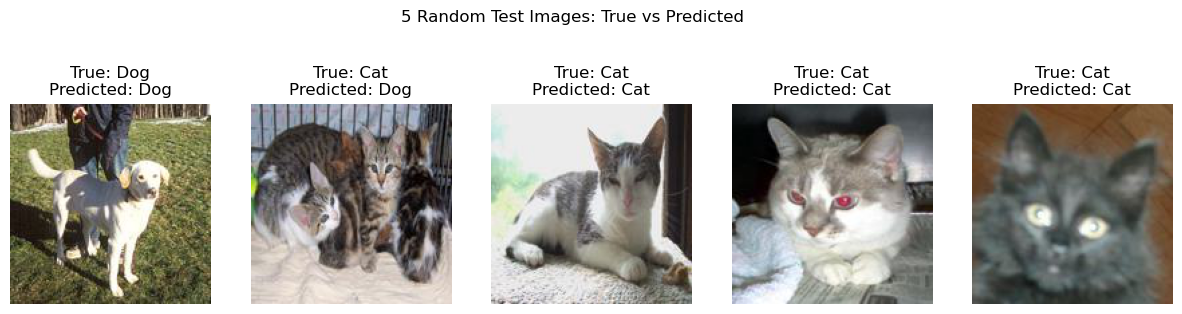

In [6]:
label_names = {0: "Cat", 1: "Dog"}

random.seed()
idxs = random.sample(range(len(images)), 5)

plt.figure(figsize=(15, 4))
for i, idx in enumerate(idxs):
    plt.subplot(1, 5, i+1)
    img = images[idx]
    if img.max() <= 1.0:
        img = (img * 255).astype("uint8")
    else:
        img = img.astype("uint8")
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"True: {label_names[int(labels[idx])]}\nPredicted: {label_names[int(y_pred[idx])]}")
plt.suptitle("5 Random Test Images: True vs Predicted")
plt.show()

Highlight at least 5 examples where the model was wrong

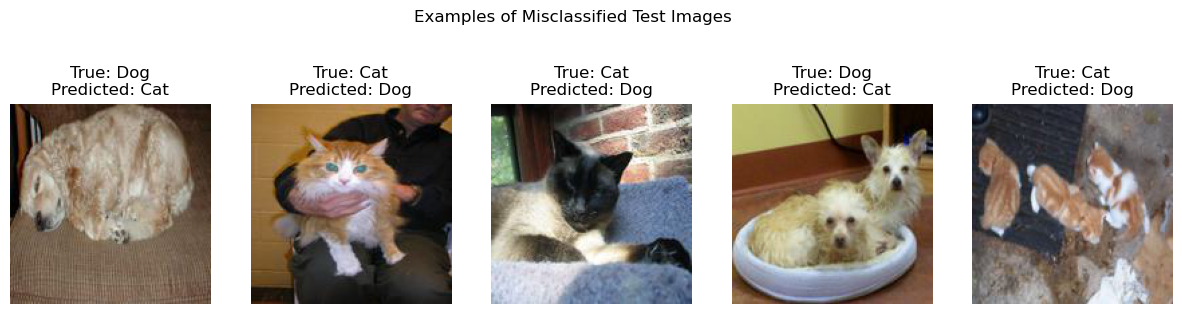

In [7]:
wrong_idx = np.where(y_pred != labels)[0]

if len(wrong_idx) > 0:
    np.random.shuffle(wrong_idx)
    n_show = min(5, len(wrong_idx))
    plt.figure(figsize=(15, 4))
    for i, idx in enumerate(wrong_idx[:n_show]):
        plt.subplot(1, n_show, i+1)
        img = images[idx]
        if img.max() <= 1.0:
            img = (img * 255).astype("uint8")
        else:
            img = img.astype("uint8")
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"True: {label_names[int(labels[idx])]}\nPredicted: {label_names[int(y_pred[idx])]}")
    plt.suptitle("Examples of Misclassified Test Images")
    plt.show()
else:
    print("No misclassified images in the test set.")

In [8]:
print(f"Test Accuracy:                                   {round(acc*100)}%")
print(f"Number of misclassified images: {len(wrong_idx)} ({round(len(wrong_idx)/(number_of_images/10)*100)}%)")

Test Accuracy:                                   72%
Number of misclassified images: 57 (28%)


### Analyze why

* images are stretched
* perhaps needs more images

(restarting kernel between each attempt)
1. Original setup
    - Result acc: 65%
2. Add data augmentation to images
    - Result acc: 66%
3. Tweak data augmentation
    - Result acc: 61% 
4. Second attempt at tweaking data augmentation
    - Result acc: 62%
5. Remove data augmentation
    - Result acc: 74%
unclear what happened or why
6. Stretch pants approach (increase number of hidden layers and neurons per hidden layer)
    - Result acc: 50% - all dogs
feels like overfitting (?)
7. decrease number of hidden layers
    - Result acc: 62%
8. back to original number of hidden layers
    - Result acc: 66%
9. decrease learning rate
    - Result acc: 74%
10. increase learning rate
    - Result acc: 50% - all cats
11. decrease learning rate a bit
    - Result acc: 68%
12. decrease learning rate again
    - Result acc: 73%
13. tried data augmentation again
    - Result acc: 71%
14. ReLU for all hidden layers
    - Result acc: 54%
15. Different activation functions
    - Result acc: 72%
16. Increase batch size
    - Result acc: 56%
17. Decrease batch size
    - Result acc: 72%
18. Decrease batch size even more
    - Result acc: 68%


    ...
20. Increase 2000 images => 4000 images
    ,,, Result acc: 




## Stretch Goals
Use transfer learning with a pre-trained network (like MobileNet or ResNet).
Compare the accuracy of your CNN vs. transfer learning.
Experiment with changing batch size, learning rate, or number of layers.